In [1]:
import os
import pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from pyproj import Transformer
import seaborn as sns
import pandas as pd

# ═══════════════════════════════════════════════════════════════
# CHANGE THIS to visualize a different day
# ═══════════════════════════════════════════════════════════════
DATE = "2003-03-03"
#   2013-02-01 — fully wet day (2462/2462 stations, ~7 mm mean)
#   2011-07-20 — mixed day (1107/2458 = 45% wet, summer storms, mean 20.5 mm)
# ═══════════════════════════════════════════════════════════════

# ── paths ──
ROOT = Path.cwd().parents[1]
os.chdir(ROOT)

VIZ_DIR = ROOT / "results" / "viz_day"
CV_PATH = ROOT / "results" / "cross_validation" / "cv_results.pkl"
OUT_DIR = ROOT / "images" / f"viz_{DATE}"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {ROOT}")
print(f"Loading from: {VIZ_DIR}")

# ── load data ──
with open(VIZ_DIR / f"predictions_{DATE}.pkl", "rb") as f:
    predictions = pickle.load(f)
with open(VIZ_DIR / f"grid_meta_{DATE}.pkl", "rb") as f:
    meta = pickle.load(f)
with open(CV_PATH, "rb") as f:
    cv_results = pickle.load(f)

# ── load variance (optional) ──
var_path = VIZ_DIR / f"variances_{DATE}.pkl"
if var_path.exists():
    with open(var_path, "rb") as f:
        variances = pickle.load(f)
    print(f"Kriging variance: loaded ({len(variances)} combinations)")
else:
    variances = None
    print("Kriging variance: not found (run updated run_viz_day.py)")

# ── load quotas for 2D vs 3D comparison (optional) ──
quota_path = VIZ_DIR / f"quotas_{DATE}.pkl"
if quota_path.exists():
    with open(quota_path, "rb") as f:
        quotas = pickle.load(f)
    print(f"Quotas: loaded ({len(quotas)} combinations)")
else:
    quotas = None
    print("Quotas: not found (run updated run_viz_day.py)")

# ── load station observations (optional) ──
stn_path = VIZ_DIR / f"stations_{DATE}.pkl"
if stn_path.exists():
    with open(stn_path, "rb") as f:
        stations = pickle.load(f)
    n_wet = int(stations["rain_indicator"].sum())
    n_total = len(stations["rain_indicator"])
    print(f"Stations: {n_total} total, {n_wet} wet ({n_wet/n_total:.0%})")
else:
    stations = None
    print("Station data: not found (run updated run_viz_day.py)")

# ── extract grid metadata ──
shape = meta["shape"]
coords = meta["coords_proj"]
elev = meta["elevation_m"]
date = meta["date"]

# Norm grids: new format has norm_grid_3d/2d, old has norm_grid or neither
norm_grid_3d = meta.get("norm_grid_3d", meta.get("norm_grid"))
norm_grid_2d = meta.get("norm_grid_2d")

print(f"\nDate: {date}")
print(f"Grid: {shape}, {meta['n_cells']:,} cells")
print(f"Combinations: {len(predictions)}")
print(f"Norm grid 3D: {'yes' if norm_grid_3d is not None else 'no'}")
print(f"Norm grid 2D: {'yes' if norm_grid_2d is not None else 'no'}")
print(f"Output dir: {OUT_DIR}")

Project root: /Users/etomengoi/Desktop/precip_interpolation_thesis
Loading from: /Users/etomengoi/Desktop/precip_interpolation_thesis/results/viz_day
Kriging variance: loaded (9 combinations)
Quotas: loaded (9 combinations)
Stations: 2458 total, 1238 wet (50%)

Date: 2003-03-03
Grid: (534, 483), 257,922 cells
Combinations: 9
Norm grid 3D: yes
Norm grid 2D: yes
Output dir: /Users/etomengoi/Desktop/precip_interpolation_thesis/images/viz_2003-03-03


In [2]:
# ── reshape to 2D grids + compute lon/lat tick positions ──
grids_2d = {k: v.reshape(shape) for k, v in predictions.items()}
elev_2d = elev.reshape(shape)

if variances is not None:
    vars_2d = {k: v.reshape(shape) for k, v in variances.items()}
    stds_2d = {k: np.sqrt(v) for k, v in vars_2d.items()}

# Transform corner coords -> lon/lat for axis labels
transformer = Transformer.from_crs("EPSG:3035", "EPSG:4326", always_xy=True)
xs = coords[:, 0].reshape(shape)
ys = coords[:, 1].reshape(shape)
lons, lats = transformer.transform(xs, ys)

# Grid origin and resolution (for converting station coords to pixel indices)
grid_x0 = xs[0, 0]
grid_y0 = ys[0, 0]
grid_dx = xs[0, 1] - xs[0, 0]  # 1000 m
grid_dy = ys[1, 0] - ys[0, 0]  # 1000 m

def station_to_pixel(stn_x, stn_y):
    """Convert station EPSG:3035 coords to pixel (col, row) indices."""
    col = (stn_x - grid_x0) / grid_dx
    row = (stn_y - grid_y0) / grid_dy
    return col, row

def add_geo_ticks(ax, lons=lons, lats=lats, nx=4, ny=5):
    """Add lon/lat tick labels to an imshow axis."""
    row_mid = shape[0] // 2
    col_mid = shape[1] // 2
    lon_row = lons[row_mid, :]
    target_lons = np.linspace(lon_row.min(), lon_row.max(), nx + 2)[1:-1]
    xtick_cols = [np.argmin(np.abs(lon_row - tl)) for tl in target_lons]
    ax.set_xticks(xtick_cols)
    ax.set_xticklabels([f"{lon_row[c]:.0f}" for c in xtick_cols], fontsize=7)
    lat_col = lats[:, col_mid]
    target_lats = np.linspace(lat_col.min(), lat_col.max(), ny + 2)[1:-1]
    ytick_rows = [np.argmin(np.abs(lat_col - tl)) for tl in target_lats]
    ax.set_yticks(ytick_rows)
    ax.set_yticklabels([f"{lat_col[r]:.1f}" for r in ytick_rows], fontsize=7)

# ── Mask near-zero precipitation so dry areas appear transparent ──
PRECIP_MASK_MM = 0.1  # values below this are transparent (no color)

def precip_cmap():
    """YlGnBu colormap with transparent masked (dry) cells."""
    cmap = plt.cm.YlGnBu.copy()
    cmap.set_bad(alpha=0)  # fully transparent for masked cells
    return cmap

def mask_dry(grid):
    """Mask grid cells below the precipitation threshold."""
    return np.ma.masked_less(grid, PRECIP_MASK_MM)

# ── Territory background: faint grey terrain + country borders ──
# Pre-compute border paths in pixel coordinates (once, reused by all plots)
import cartopy.feature as cfeature
from shapely.ops import transform as shapely_transform
from pyproj import Transformer as _Transformer

_t_ll_to_proj = _Transformer.from_crs("EPSG:4326", "EPSG:3035", always_xy=True).transform
_border_paths_px = []

for geom in cfeature.BORDERS.geometries():
    projected = shapely_transform(_t_ll_to_proj, geom)
    if projected.is_empty:
        continue
    if projected.geom_type == "MultiLineString":
        lines = list(projected.geoms)
    else:
        lines = [projected]
    for line in lines:
        bx, by = np.array(line.coords).T
        px_col = (bx - grid_x0) / grid_dx
        px_row = (by - grid_y0) / grid_dy
        # Keep segments that cross the grid extent
        in_view = ((px_col > -50) & (px_col < shape[1] + 50) &
                   (px_row > -50) & (px_row < shape[0] + 50))
        if in_view.any():
            _border_paths_px.append((px_col, px_row))

# Also coastlines
_coast_paths_px = []
for geom in cfeature.COASTLINE.geometries():
    projected = shapely_transform(_t_ll_to_proj, geom)
    if projected.is_empty:
        continue
    if projected.geom_type == "MultiLineString":
        lines = list(projected.geoms)
    else:
        lines = [projected]
    for line in lines:
        bx, by = np.array(line.coords).T
        px_col = (bx - grid_x0) / grid_dx
        px_row = (by - grid_y0) / grid_dy
        in_view = ((px_col > -50) & (px_col < shape[1] + 50) &
                   (px_row > -50) & (px_row < shape[0] + 50))
        if in_view.any():
            _coast_paths_px.append((px_col, px_row))

print(f"Borders: {len(_border_paths_px)} segments, Coastlines: {len(_coast_paths_px)} segments")

def draw_background(ax):
    """Draw light grey terrain + country borders as map context."""
    # Faint elevation shading
    ax.imshow(elev_2d, origin="lower", cmap="Greys", alpha=0.10,
              aspect="equal", interpolation="nearest")
    # Country borders
    for px_col, px_row in _border_paths_px:
        ax.plot(px_col, px_row, color="#888888", linewidth=0.6, alpha=0.5)
    # Coastlines
    for px_col, px_row in _coast_paths_px:
        ax.plot(px_col, px_row, color="#888888", linewidth=0.8, alpha=0.5)
    ax.set_xlim(0, shape[1])
    ax.set_ylim(0, shape[0])

# Consistent colorbar range across all 9 maps
all_vals = np.concatenate([v.ravel() for v in grids_2d.values()])
vmin, vmax = 0, np.percentile(all_vals, 99)
print(f"Color range: {vmin:.1f} - {vmax:.1f} mm")
print(f"Dry mask: < {PRECIP_MASK_MM} mm shown as transparent")

Borders: 5 segments, Coastlines: 2 segments
Color range: 0.0 - 5.6 mm
Dry mask: < 0.1 mm shown as transparent


## Station Observations (ground truth)

Actual measured precipitation at each station for this day. Dry stations shown as grey crosses, wet stations as colored circles sized by precipitation amount.

/var/folders/ql/4xq99k013n18xqmfg3p3mx_h0000gn/T/ipykernel_86360/709787586.py:52: UserWarning: You passed a edgecolor/edgecolors ('grey') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax2.scatter(stn_col[~wet], stn_row[~wet], c="none", edgecolors="grey",


Saved: /Users/etomengoi/Desktop/precip_interpolation_thesis/images/viz_2003-03-03/stations_vs_kriging_2003-03-03.png


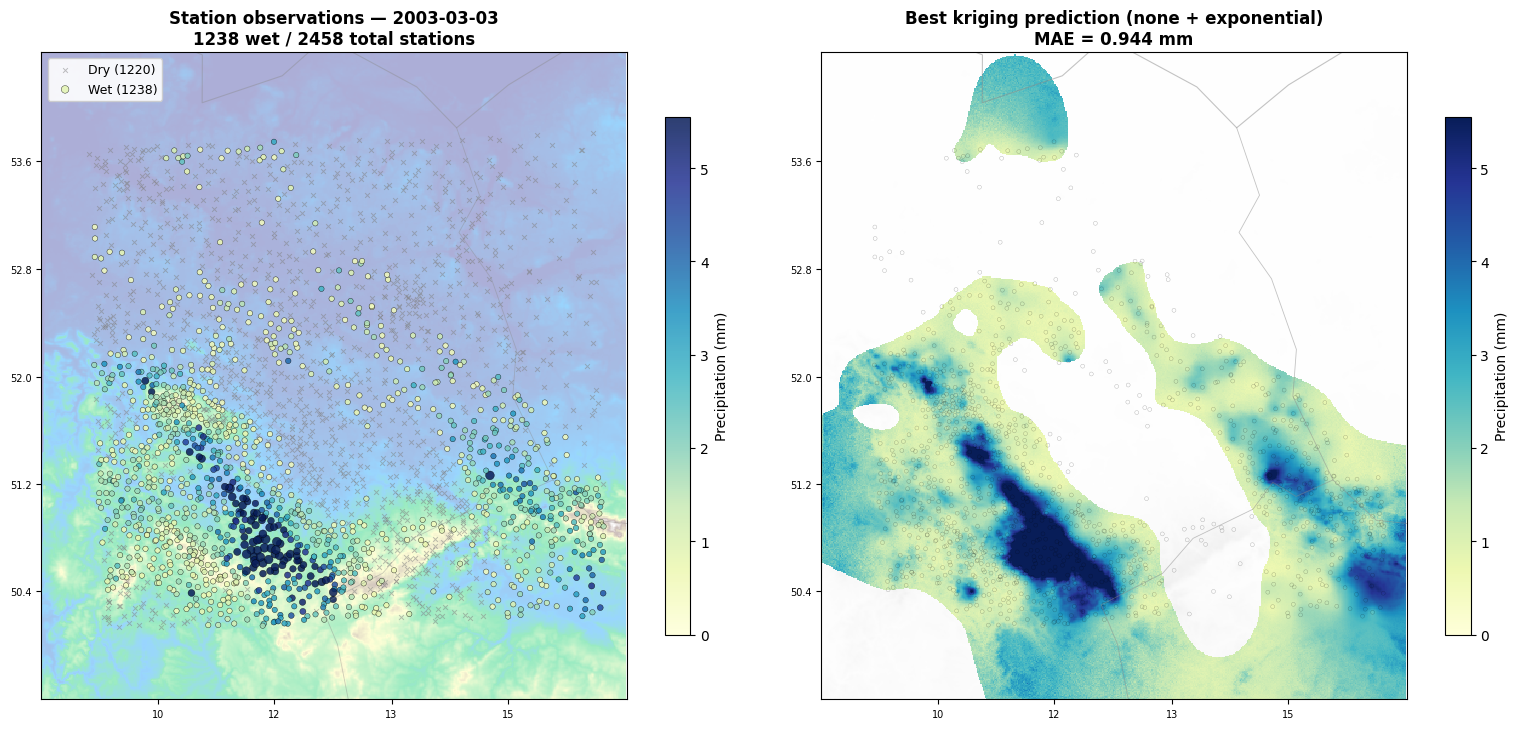

In [3]:
if stations is not None:
    stn_col, stn_row = station_to_pixel(stations["x_proj"], stations["y_proj"])
    precip = stations["precip_mm"]
    wet = stations["rain_indicator"].astype(bool)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

    # ── Left panel: station observations on elevation background ──
    ax1.imshow(elev_2d, origin="lower", cmap="terrain", aspect="equal",
               interpolation="nearest", alpha=0.4)

    # Dry stations: small grey crosses
    if (~wet).any():
        ax1.scatter(stn_col[~wet], stn_row[~wet], c="grey", marker="x",
                    s=12, alpha=0.5, linewidths=0.7, label=f"Dry ({(~wet).sum()})")

    # Wet stations: colored circles, size proportional to precipitation
    if wet.any():
        sizes = np.clip(precip[wet] * 4, 15, 250)
        sc = ax1.scatter(stn_col[wet], stn_row[wet], c=precip[wet],
                         cmap="YlGnBu", vmin=0, vmax=vmax,
                         s=sizes, edgecolors="k", linewidths=0.3, alpha=0.85,
                         label=f"Wet ({wet.sum()})")
        fig.colorbar(sc, ax=ax1, label="Precipitation (mm)", shrink=0.8)

    # Borders on station map too
    for px_col, px_row in _border_paths_px:
        ax1.plot(px_col, px_row, color="#888888", linewidth=0.6, alpha=0.4)
    for px_col, px_row in _coast_paths_px:
        ax1.plot(px_col, px_row, color="#888888", linewidth=0.8, alpha=0.4)

    ax1.set_xlim(0, shape[1])
    ax1.set_ylim(0, shape[0])
    add_geo_ticks(ax1, lons, lats)
    ax1.legend(loc="upper left", fontsize=9, framealpha=0.9)
    ax1.set_title(f"Station observations — {date}\n"
                  f"{wet.sum()} wet / {len(wet)} total stations",
                  fontsize=12, fontweight="bold")

    # ── Right panel: best kriging prediction for comparison ──
    best_key_tmp = min(cv_results, key=lambda k: cv_results[k]["crps_mm"])
    best_label_tmp = f"{best_key_tmp[0]} + {best_key_tmp[1]}"

    draw_background(ax2)
    im2 = ax2.imshow(mask_dry(grids_2d[best_key_tmp]), origin="lower",
                     cmap=precip_cmap(), vmin=vmin, vmax=vmax,
                     aspect="equal", interpolation="nearest")
    # Overlay station positions as small dots for reference
    ax2.scatter(stn_col[wet], stn_row[wet], c="none", edgecolors="k",
                s=8, linewidths=0.3, alpha=0.3)
    if (~wet).any():
        ax2.scatter(stn_col[~wet], stn_row[~wet], c="none", edgecolors="grey",
                    marker="x", s=6, linewidths=0.3, alpha=0.3)
    fig.colorbar(im2, ax=ax2, label="Precipitation (mm)", shrink=0.8)
    add_geo_ticks(ax2, lons, lats)
    ax2.set_title(f"Best kriging prediction ({best_label_tmp})\n"
                  f"MAE = {cv_results[best_key_tmp]['mae_mm']:.3f} mm",
                  fontsize=12, fontweight="bold")

    plt.tight_layout()
    fig.savefig(OUT_DIR / f"stations_vs_kriging_{date}.png", dpi=200, bbox_inches="tight")
    print(f"Saved: {OUT_DIR / f'stations_vs_kriging_{date}.png'}")
    plt.show()
else:
    print("No station data — skipping. Run updated run_viz_day.py to generate.")

## 3x3 Prediction Maps

In [ ]:
TRANSFORMS = ["none", "log", "normal_score"]
MODELS = ["spherical", "exponential", "gaussian"]
TR_LABELS = {"none": "No transform", "log": "Log", "normal_score": "Normal-score"}
MODEL_LABELS = {"spherical": "Spherical", "exponential": "Exponential", "gaussian": "Gaussian"}

# Find best combo by CRPS
best_key = min(cv_results, key=lambda k: cv_results[k]["crps_mm"])

# ── plot ──
fig, axes = plt.subplots(3, 3, figsize=(16, 14))
cmap = precip_cmap()

for i, tr in enumerate(TRANSFORMS):
    for j, vm in enumerate(MODELS):
        ax = axes[i, j]
        key = (tr, vm)
        grid = grids_2d[key]

        draw_background(ax)
        im = ax.imshow(mask_dry(grid), origin="lower", cmap=cmap, vmin=vmin, vmax=vmax,
                       aspect="equal", interpolation="nearest")

        # Title: transform + model + metrics
        r = cv_results[key]
        star = "  ***" if key == best_key else ""
        ax.set_title(
            f"{TR_LABELS[tr]} + {MODEL_LABELS[vm]}\n"
            f"MAE = {r['mae_mm']:.3f} mm   CRPS = {r['crps_mm']:.3f} mm{star}",
            fontsize=9, fontweight="bold" if key == best_key else "normal",
        )
        add_geo_ticks(ax)

    # Row label
    axes[i, 0].set_ylabel(TR_LABELS[tr], fontsize=11, fontweight="bold")

# Shared colorbar
fig.subplots_adjust(right=0.91, hspace=0.35, wspace=0.18)
cbar_ax = fig.add_axes([0.93, 0.15, 0.015, 0.7])
fig.colorbar(im, cax=cbar_ax, label="Precipitation (mm)")

fig.suptitle(f"Ordinary Kriging — 9 combinations — {date}", fontsize=14, fontweight="bold", y=0.98)

fig.savefig(OUT_DIR / f"predictions_3x3_{date}.png", dpi=200, bbox_inches="tight")
print(f"Saved: {OUT_DIR / f'predictions_3x3_{date}.png'}")
plt.show()

## Difference Maps (each combo vs. best)

In [ ]:
# Difference maps: each combo minus the best combo
best_grid = grids_2d[best_key]
diff_max = max(np.abs(g - best_grid).max() for k, g in grids_2d.items() if k != best_key)
diff_lim = min(diff_max, 5.0)  # cap at 5 mm for readability

fig, axes = plt.subplots(3, 3, figsize=(16, 14))

for i, tr in enumerate(TRANSFORMS):
    for j, vm in enumerate(MODELS):
        ax = axes[i, j]
        key = (tr, vm)

        draw_background(ax)

        if key == best_key:
            im = ax.imshow(mask_dry(best_grid), origin="lower", cmap=precip_cmap(),
                           vmin=vmin, vmax=vmax,
                           aspect="equal", interpolation="nearest")
            ax.set_title(f"{TR_LABELS[tr]} + {MODEL_LABELS[vm]}\n(BEST — reference)",
                         fontsize=9, fontweight="bold")
        else:
            diff = grids_2d[key] - best_grid
            # Make diff map semi-transparent so background shows through
            diff_cmap = plt.cm.RdBu_r.copy()
            diff_cmap.set_bad(alpha=0)
            im = ax.imshow(diff, origin="lower", cmap=diff_cmap, vmin=-diff_lim, vmax=diff_lim,
                           aspect="equal", interpolation="nearest")
            r_diff = cv_results[key]["crps_mm"] - cv_results[best_key]["crps_mm"]
            ax.set_title(
                f"{TR_LABELS[tr]} + {MODEL_LABELS[vm]}\n"
                f"mean diff = {diff.mean():+.3f} mm   CRPS diff = {r_diff:+.3f}",
                fontsize=9)
        add_geo_ticks(ax)
    axes[i, 0].set_ylabel(TR_LABELS[tr], fontsize=11, fontweight="bold")

fig.subplots_adjust(right=0.91, hspace=0.35, wspace=0.18)
cbar_ax = fig.add_axes([0.93, 0.15, 0.015, 0.7])
fig.colorbar(plt.cm.ScalarMappable(cmap="RdBu_r",
             norm=plt.Normalize(-diff_lim, diff_lim)),
             cax=cbar_ax, label="Difference vs. best (mm)")

best_label = f"{TR_LABELS[best_key[0]]} + {MODEL_LABELS[best_key[1]]}"
fig.suptitle(f"Prediction difference vs. best ({best_label}) — {date}",
             fontsize=14, fontweight="bold", y=0.98)

fig.savefig(OUT_DIR / f"predictions_diff_{date}.png", dpi=200, bbox_inches="tight")
print(f"Saved: {OUT_DIR / f'predictions_diff_{date}.png'}")
plt.show()

## LOO-CV Performance Heatmap

In [ ]:
import seaborn as sns

heatmap_mae = np.array([[cv_results[(tr, vm)]["mae_mm"] for vm in MODELS] for tr in TRANSFORMS])
heatmap_crps = np.array([[cv_results[(tr, vm)]["crps_mm"] for vm in MODELS] for tr in TRANSFORMS])

tr_labels = [TR_LABELS[t] for t in TRANSFORMS]
vm_labels = [MODEL_LABELS[m] for m in MODELS]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

sns.heatmap(heatmap_mae, annot=True, fmt=".3f", cmap="YlOrRd",
            xticklabels=vm_labels, yticklabels=tr_labels, ax=ax1,
            cbar_kws={"label": "MAE (mm)"}, linewidths=0.5)
ax1.set_title("MAE (mm) — full LOO-CV", fontsize=12, fontweight="bold")

sns.heatmap(heatmap_crps, annot=True, fmt=".4f", cmap="YlOrRd",
            xticklabels=vm_labels, yticklabels=tr_labels, ax=ax2,
            cbar_kws={"label": "CRPS (mm)"}, linewidths=0.5)
ax2.set_title("CRPS (mm) — full LOO-CV", fontsize=12, fontweight="bold")

# Mark best cell
best_i = TRANSFORMS.index(best_key[0])
best_j = MODELS.index(best_key[1])
for ax in (ax1, ax2):
    ax.add_patch(plt.Rectangle((best_j, best_i), 1, 1, fill=False, edgecolor="black", lw=3))

plt.tight_layout()
fig.savefig(OUT_DIR / f"cv_heatmap_{date}.png", dpi=200, bbox_inches="tight")
print(f"Saved: {OUT_DIR / f'cv_heatmap_{date}.png'}")
plt.show()

## Elevation overlay (best prediction)

In [ ]:
# Best prediction with elevation contours overlaid
best_grid = grids_2d[best_key]
best_label = f"{TR_LABELS[best_key[0]]} + {MODEL_LABELS[best_key[1]]}"

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

draw_background(ax1)
im1 = ax1.imshow(mask_dry(best_grid), origin="lower", cmap=precip_cmap(),
                 vmin=vmin, vmax=vmax,
                 aspect="equal", interpolation="nearest")
contour_levels = [100, 200, 400, 600, 800]
cs = ax1.contour(elev_2d, levels=contour_levels, colors="k", linewidths=0.4, alpha=0.5)
ax1.clabel(cs, fontsize=6, fmt="%d m")
fig.colorbar(im1, ax=ax1, label="Precipitation (mm)", shrink=0.8)
add_geo_ticks(ax1)
ax1.set_title(f"Best prediction: {best_label}\n{date}", fontsize=11, fontweight="bold")

im2 = ax2.imshow(elev_2d, origin="lower", cmap="terrain", aspect="equal", interpolation="nearest")
# Add borders to elevation map too
for px_col, px_row in _border_paths_px:
    ax2.plot(px_col, px_row, color="#555555", linewidth=0.6, alpha=0.5)
for px_col, px_row in _coast_paths_px:
    ax2.plot(px_col, px_row, color="#555555", linewidth=0.8, alpha=0.5)
ax2.set_xlim(0, shape[1])
ax2.set_ylim(0, shape[0])
fig.colorbar(im2, ax=ax2, label="Elevation (m)", shrink=0.8)
add_geo_ticks(ax2)
ax2.set_title(f"DEM elevation\n{shape[0]}x{shape[1]} grid, 1 km", fontsize=11, fontweight="bold")

plt.tight_layout()
fig.savefig(OUT_DIR / f"best_prediction_elev_{date}.png", dpi=200, bbox_inches="tight")
print(f"Saved: {OUT_DIR / f'best_prediction_elev_{date}.png'}")
plt.show()

## Kriging Uncertainty (std. deviation in mm)

Kriging variance is propagated through Monte Carlo back-transformation: `var_mm² = var_quota × norm_grid²`.
This gives uncertainty in physical units (mm). Higher values = less data nearby = less certain prediction.

In [ ]:
if variances is not None:
    all_stds = np.concatenate([v.ravel() for v in stds_2d.values()])
    std_vmin, std_vmax = 0, np.percentile(all_stds, 99)

    fig, axes = plt.subplots(3, 3, figsize=(16, 14))

    for i, tr in enumerate(TRANSFORMS):
        for j, vm in enumerate(MODELS):
            ax = axes[i, j]
            key = (tr, vm)
            std_grid = stds_2d[key]

            draw_background(ax)
            im = ax.imshow(std_grid, origin="lower", cmap="magma_r",
                           vmin=std_vmin, vmax=std_vmax,
                           aspect="equal", interpolation="nearest")
            ax.set_title(
                f"{TR_LABELS[tr]} + {MODEL_LABELS[vm]}\n"
                f"mean std = {std_grid.mean():.3f} mm   max = {std_grid.max():.3f} mm",
                fontsize=9,
                fontweight="bold" if key == best_key else "normal",
            )
            add_geo_ticks(ax)
        axes[i, 0].set_ylabel(TR_LABELS[tr], fontsize=11, fontweight="bold")

    fig.subplots_adjust(right=0.91, hspace=0.35, wspace=0.18)
    cbar_ax = fig.add_axes([0.93, 0.15, 0.015, 0.7])
    fig.colorbar(im, cax=cbar_ax, label="Kriging std (mm)")

    fig.suptitle(f"Kriging uncertainty (std. deviation) — {date}",
                 fontsize=14, fontweight="bold", y=0.98)

    fig.savefig(OUT_DIR / f"uncertainty_3x3_{date}.png", dpi=200, bbox_inches="tight")
    print(f"Saved: {OUT_DIR / f'uncertainty_3x3_{date}.png'}")
    plt.show()
else:
    print("No variance data — skipping. Run updated run_viz_day.py to generate.")

In [ ]:
if variances is not None:
    best_label = f"{TR_LABELS[best_key[0]]} + {MODEL_LABELS[best_key[1]]}"
    best_std = stds_2d[best_key]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    draw_background(ax1)
    im1 = ax1.imshow(mask_dry(grids_2d[best_key]), origin="lower", cmap=precip_cmap(),
                     vmin=vmin, vmax=vmax, aspect="equal", interpolation="nearest")
    fig.colorbar(im1, ax=ax1, label="Precipitation (mm)", shrink=0.8)
    add_geo_ticks(ax1)
    ax1.set_title(f"Prediction: {best_label}\n{date}", fontsize=11, fontweight="bold")

    draw_background(ax2)
    im2 = ax2.imshow(best_std, origin="lower", cmap="magma_r",
                     vmin=0, vmax=np.percentile(best_std, 99),
                     aspect="equal", interpolation="nearest")
    fig.colorbar(im2, ax=ax2, label="Kriging std (mm)", shrink=0.8)
    add_geo_ticks(ax2)
    ax2.set_title(f"Uncertainty: {best_label}\n"
                  f"mean = {best_std.mean():.3f} mm, max = {best_std.max():.3f} mm",
                  fontsize=11, fontweight="bold")

    plt.tight_layout()
    fig.savefig(OUT_DIR / f"best_vs_uncertainty_{date}.png", dpi=200, bbox_inches="tight")
    print(f"Saved: {OUT_DIR / f'best_vs_uncertainty_{date}.png'}")
    plt.show()

## Summary Table

In [ ]:
import pandas as pd

rows = []
for (tr, vm), r in sorted(cv_results.items(), key=lambda x: x[1]["crps_mm"]):
    pred = predictions[(tr, vm)]
    rows.append({
        "Transform": TR_LABELS[tr],
        "Variogram": MODEL_LABELS[vm],
        "MAE (mm)": round(r["mae_mm"], 3),
        "CRPS (mm)": round(r["crps_mm"], 4),
        "n LOO": f"{r['n']:,}",
        "Pred min": round(pred.min(), 2),
        "Pred max": round(pred.max(), 2),
        "Pred mean": round(pred.mean(), 2),
    })

df = pd.DataFrame(rows)
print(f"Best: {df.iloc[0]['Transform']} + {df.iloc[0]['Variogram']}  "
      f"(CRPS = {df.iloc[0]['CRPS (mm)']})\n")
df

## Elevation Effect: TPS 3D vs TPS 2D (best combination)

The kriging model interpolates `precip_quota = daily / monthly_norm` in transformed space.
To recover precipitation in mm, the predicted quota is multiplied by a **monthly normal grid** — 
a spatially-varying climatological mean interpolated via Thin-Plate Spline (TPS).

Three options for the monthly norm (Haylock et al. 2008):
- **Station**: use the real station norm (best, but only at known points — used in LOO-CV)
- **TPS 3D**: interpolate from stations using (X, Y, Elevation) — captures orographic effects
- **TPS 2D**: interpolate using (X, Y) only — no elevation information

The DEM experiment (`run_dem.py`) showed TPS 3D outperforms TPS 2D because higher elevation 
correlates with higher precipitation normals. Below we compare the best model's predictions 
under both regimes.

In [ ]:
can_compare = (quotas is not None and norm_grid_2d is not None and norm_grid_3d is not None)

if can_compare:
    best_quota = quotas[best_key]
    pred_3d = np.maximum(best_quota * norm_grid_3d, 0.0).reshape(shape)
    pred_2d = np.maximum(best_quota * norm_grid_2d, 0.0).reshape(shape)
    diff_3d_2d = pred_3d - pred_2d
    norm_3d_2d = norm_grid_3d.reshape(shape)
    norm_2d_2d = norm_grid_2d.reshape(shape)

    best_label = f"{TR_LABELS[best_key[0]]} + {MODEL_LABELS[best_key[1]]}"
    common_vmax = max(np.percentile(pred_3d, 99), np.percentile(pred_2d, 99))

    fig, axes = plt.subplots(2, 3, figsize=(18, 11))
    cmap = precip_cmap()

    # ── Top row: predictions ──
    draw_background(axes[0, 0])
    im0 = axes[0, 0].imshow(mask_dry(pred_3d), origin="lower", cmap=cmap,
                             vmin=0, vmax=common_vmax, aspect="equal")
    axes[0, 0].set_title(f"TPS 3D (X, Y, Elevation)\n{best_label}", fontsize=10, fontweight="bold")
    fig.colorbar(im0, ax=axes[0, 0], label="mm", shrink=0.8)

    draw_background(axes[0, 1])
    im1 = axes[0, 1].imshow(mask_dry(pred_2d), origin="lower", cmap=cmap,
                             vmin=0, vmax=common_vmax, aspect="equal")
    axes[0, 1].set_title(f"TPS 2D (X, Y only)\n{best_label}", fontsize=10, fontweight="bold")
    fig.colorbar(im1, ax=axes[0, 1], label="mm", shrink=0.8)

    dlim = np.percentile(np.abs(diff_3d_2d), 99)
    draw_background(axes[0, 2])
    im2 = axes[0, 2].imshow(diff_3d_2d, origin="lower", cmap="RdBu_r",
                             vmin=-dlim, vmax=dlim, aspect="equal")
    axes[0, 2].set_title(f"Difference (3D - 2D)\nmean = {diff_3d_2d.mean():+.3f} mm",
                          fontsize=10, fontweight="bold")
    fig.colorbar(im2, ax=axes[0, 2], label="mm", shrink=0.8)

    # ── Bottom row: monthly norm grids + elevation ──
    norm_vmin = min(norm_3d_2d.min(), norm_2d_2d.min())
    norm_vmax = max(np.percentile(norm_3d_2d, 99), np.percentile(norm_2d_2d, 99))
    month_name = ["Jan","Feb","Mar","Apr","May","Jun",
                  "Jul","Aug","Sep","Oct","Nov","Dec"][int(date[5:7]) - 1]

    draw_background(axes[1, 0])
    im3 = axes[1, 0].imshow(norm_3d_2d, origin="lower", cmap="YlOrRd",
                             vmin=norm_vmin, vmax=norm_vmax, aspect="equal")
    axes[1, 0].set_title(f"Monthly norm — TPS 3D\n{month_name} mean: {norm_3d_2d.mean():.1f} mm",
                          fontsize=10)
    fig.colorbar(im3, ax=axes[1, 0], label="mm/month", shrink=0.8)

    draw_background(axes[1, 1])
    im4 = axes[1, 1].imshow(norm_2d_2d, origin="lower", cmap="YlOrRd",
                             vmin=norm_vmin, vmax=norm_vmax, aspect="equal")
    axes[1, 1].set_title(f"Monthly norm — TPS 2D\n{month_name} mean: {norm_2d_2d.mean():.1f} mm",
                          fontsize=10)
    fig.colorbar(im4, ax=axes[1, 1], label="mm/month", shrink=0.8)

    norm_diff = norm_3d_2d - norm_2d_2d
    ndlim = np.percentile(np.abs(norm_diff), 99)
    draw_background(axes[1, 2])
    im5 = axes[1, 2].imshow(norm_diff, origin="lower", cmap="RdBu_r",
                             vmin=-ndlim, vmax=ndlim, aspect="equal")
    cs = axes[1, 2].contour(elev_2d, levels=[200, 400, 600, 800], colors="k",
                             linewidths=0.4, alpha=0.6)
    axes[1, 2].clabel(cs, fontsize=6, fmt="%d m")
    axes[1, 2].set_title(f"Norm difference (3D - 2D)\nwith elevation contours",
                          fontsize=10, fontweight="bold")
    fig.colorbar(im5, ax=axes[1, 2], label="mm/month", shrink=0.8)

    for ax in axes.flat:
        add_geo_ticks(ax)

    fig.suptitle(f"Elevation effect on predictions — {date}\n"
                 f"TPS 3D captures orographic enhancement of monthly normals",
                 fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    fig.savefig(OUT_DIR / f"elevation_effect_2d_vs_3d_{date}.png", dpi=200, bbox_inches="tight")
    print(f"Saved: {OUT_DIR / f'elevation_effect_2d_vs_3d_{date}.png'}")
    plt.show()
else:
    missing = []
    if quotas is None: missing.append("quotas")
    if norm_grid_2d is None: missing.append("norm_grid_2d")
    if norm_grid_3d is None: missing.append("norm_grid_3d")
    print(f"Cannot compare 2D vs 3D — missing: {', '.join(missing)}")
    print("Run updated run_viz_day.py to generate all artefacts.")